# 07 — EDA Blocco 3: Abusi domestici e sicurezza minori

**Fase PACE**: Analyze  
**Obiettivo**: analizzare i reati domestici in profondità — volume, trend, 
profilo delle vittime e pattern nei modus operandi. Focus specifico sulla 
sicurezza dei minori con distinzione tra bambini (0-12), adolescenti (13-17) 
e adulti (18+).

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q3.1 — Panoramica reati domestici: volume, trend annuale, distribuzione per area
- Q3.2 — Confronto profilo vittime: reati domestici vs non-domestici
- Q3.3 — Distribuzione per fasce di età nelle vittime di reati domestici
- Q3.4 — Pattern nei Mocodes per reati domestici (richiede MO_CODES.txt)

**Nota**: i reati domestici sono identificati tramite la colonna `is_domestic` 
(True/False) creata in fase di feature engineering. Totale: 225.938 record (7.3% 
del dataset).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q3.1 — Panoramica reati domestici

Analizziamo i reati domestici (`is_domestic == True`) in tre dimensioni:
volume complessivo sul periodo 2010–2024, trend annuale, e distribuzione 
per area LAPD.

### Q3.1 - Volume dei reati domestici

In [2]:
distribution_domestic_crime_df = (
    df
    .groupby('is_domestic', as_index = False)
    .agg(count = ('is_domestic', 'count'))
).copy()

print(distribution_domestic_crime_df.head())

   is_domestic    count
0        False  2853486
1         True   225938


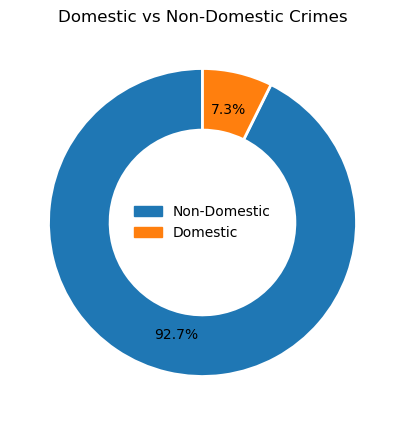

In [3]:
label_map = {True: 'Domestic', False: 'Non-Domestic'}
distribution_domestic_crime_df['label'] = distribution_domestic_crime_df['is_domestic'].map(label_map)

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(
    distribution_domestic_crime_df['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'},
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

labels = distribution_domestic_crime_df['label'].tolist()
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=wedges[i].get_facecolor(), label=labels[i])
    for i in range(len(wedges))
]

ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=10
)

ax.set_title('Domestic vs Non-Domestic Crimes')

plt.savefig('../../outputs/07_eda_block3/15_donut_domestic_vs_nondomestic.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q3.1 — Volume reati domestici

I reati domestici rappresentano il **7.3%** del totale dei crimini registrati 
dal LAPD nel periodo 2010–2024 (225.938 su 3.079.424 record).

**Nota metodologica**: questa percentuale va interpretata come limite inferiore, 
non come stima accurata del fenomeno reale, per due ragioni:

- **Sottodenuncia**: i reati domestici sono storicamente tra i più 
  sottodenunciati. Le vittime spesso non denunciano per paura di ritorsioni, 
  dipendenza economica dal perpetratore, vergogna o desiderio di proteggere 
  i figli coinvolti.
- **Classificazione**: il flag `is_domestic` è basato su parole chiave nei 
  codici LAPD (`INTIMATE PARTNER`, `CHILD ABUSE`, ecc.). Reati con dinamiche 
  domestiche ma classificati con codici generici (es. `BATTERY - SIMPLE 
  ASSAULT` senza specificazione del contesto) non vengono catturati.

Il dato reale è quasi certamente più alto di quello registrato.

### Creazione DataFrame dedicato ai reati domestici

In [4]:
q3_df = df[df['is_domestic'] == True].copy()
q3_df['is_domestic'].value_counts()

is_domestic
True    225938
Name: count, dtype: int64

### Q3.1 - Trend temporale dei reati domestici

In [5]:
q31_df_trend = (
    q3_df
    .groupby('year', as_index = False)
    .agg(count = ('year', 'count'))
)
print(q31_df_trend.head())

   year  count
0  2010  15037
1  2011  14223
2  2012  14489
3  2013  13540
4  2014  15771


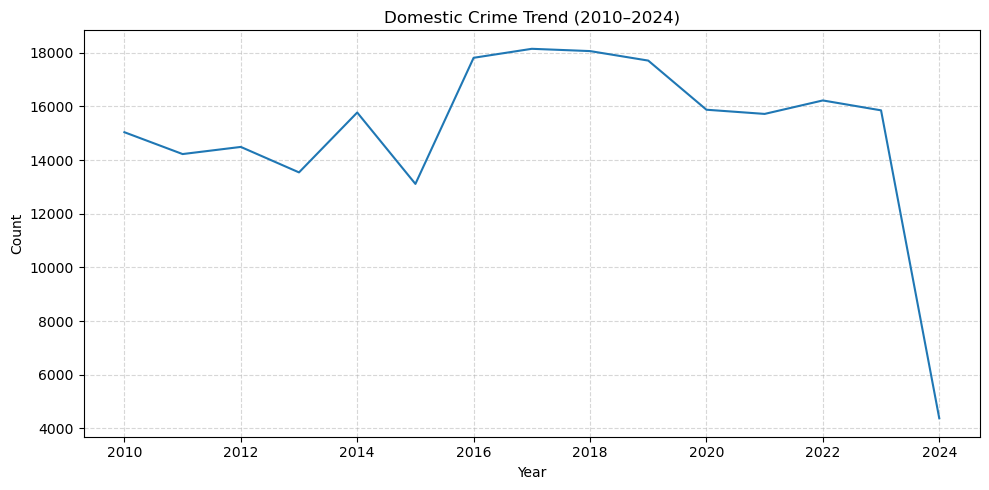

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=q31_df_trend,
    x='year',
    y='count',
    ax=ax
)

ax.set_title('Domestic Crime Trend (2010–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/16_lineplot_domestic_crime_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q3.1 — Trend annuale reati domestici

**Tendenza generale**: il trend mostra tre fasi distinte nel periodo 
2010–2024.

**2010–2015 — Fase oscillante**: i reati domestici oscillano tra 13.000 
e 15.000 con un picco nel 2014 seguito da un calo nel 2015. Il minimo 
del 2015 è coerente con l'anomalia classificatoria LAPD già documentata 
nei blocchi precedenti — non rappresenta un miglioramento reale.

**2016–2018 — Picco**: balzo da ~13.000 a ~18.000 in un solo anno (+38%). 
La rapidità e l'entità dell'aumento suggerisce un possibile cambiamento 
nelle politiche di registrazione LAPD o l'effetto di campagne di 
sensibilizzazione che hanno aumentato le denunce in quel periodo. 
Da verificare con fonti esterne nella relazione finale.

**2019–2023 — Calo progressivo**: dato contro-intuitivo rispetto alle 
aspettative. La letteratura criminologica internazionale ha documentato 
un aumento dei reati domestici durante i lockdown COVID nella maggior 
parte delle città. Los Angeles mostra invece un trend decrescente.

Tre possibili spiegazioni, non mutuamente esclusive:
- Cambiamenti nelle politiche di classificazione del LAPD
- Programmi specifici di intervento sulla violenza domestica attivati 
  durante il COVID
- **Aumento della sottodenuncia**: con le vittime costrette in casa con 
  il perpetratore, denunciare era ancora più difficile del solito. 
  Il calo potrebbe non riflettere una riduzione reale della violenza 
  ma un aumento della sottodenuncia — ipotesi metodologicamente più 
  preoccupante e da segnalare esplicitamente nella relazione finale.

**2024**: crollo a ~4.300 record. Come documentato in precedenza, il dato 
è incompleto e non va interpretato come tendenza reale.

### Q3.1 - Distribuzione per area LAPD

In [7]:
q31_df_areaDist = (
    q3_df
    .groupby('AREA NAME', as_index=False)
    .agg(count = ('AREA NAME', 'count'))
).sort_values('count', ascending = False)

print(q31_df_areaDist.head())

      AREA NAME  count
0   77th Street  21073
14    Southeast  17418
15    Southwest  15459
7       Mission  13022
9        Newton  12984


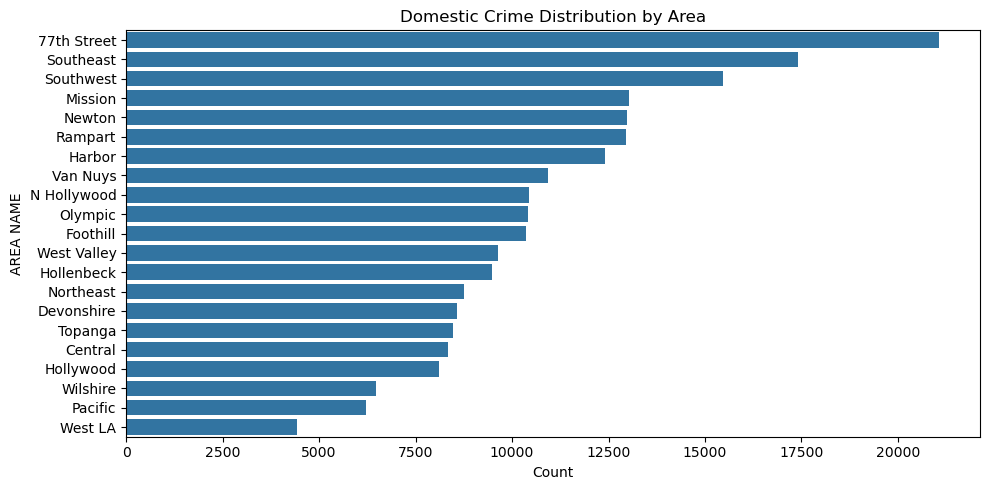

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=q31_df_areaDist,
    x='count',
    y='AREA NAME',
    ax=ax
)

ax.set_title('Domestic Crime Distribution by Area')
ax.set_xlabel('Count')
ax.set_ylabel('AREA NAME')

plt.tight_layout()
plt.savefig('../../outputs/07_eda_block3/17_barh_domestic_crime_by_area.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q3.1 — Distribuzione per area LAPD

Il grafico mostra una distribuzione disomogenea dei reati domestici tra 
le 21 aree LAPD, con tre blocchi distinti:

- **Blocco alto** — 77th Street (21.073), Southeast (17.431), Southwest 
  (15.726): le tre aree con il maggior volume di reati domestici, con 
  un distacco significativo rispetto al resto.

- **Blocco intermedio** — Mission, Newton, Rampart, Harbor (~12.000–13.000): 
  gruppo di aree con valori simili tra loro.

- **Blocco basso** — West LA (4.447), Pacific (6.306), Wilshire (6.990): 
  le tre aree con il minor volume di reati domestici registrati.

**Nota metodologica**: i valori sono conteggi assoluti. Senza dati di 
popolazione per distretto non è possibile calcolare il tasso per 1.000 
abitanti, che potrebbe modificare la classifica.

## 3. Q3.2 — Confronto profilo vittime: reati domestici vs non-domestici

Confrontiamo il profilo demografico delle vittime (sesso, età, etnia) 
tra reati domestici e non-domestici. Obiettivo: identificare se esistono 
differenze significative nel profilo della vittima a seconda del contesto 
del reato.

In [9]:
q32_df = df[['age_group', 'Vict Sex', 'Vict Descent', 'is_domestic']].copy()

print(q32_df.head())

  age_group Vict Sex Vict Descent  is_domestic
0     Adult        M            H        False
1       NaN        M            W        False
2       NaN        M            H        False
3     Adult        F            W        False
4     Adult        F            H        False


In [12]:
q32_df_sex = (
    df
    .groupby(['Vict Sex', 'is_domestic'], as_index=False)
    .agg(count = ('Vict Sex', 'count'))
).copy()

q32_df_age = (
    df
    .groupby(['age_group', 'is_domestic'], as_index=False, observed=True)
    .agg(count = ('Vict Age', 'count'))
).copy()

q32_df_descent = (
    df
    .groupby(['Vict Descent', 'is_domestic'], as_index=False)
    .agg(count = ('Vict Descent', 'count'))
).copy()

print("Sex df")
print(q32_df_sex.head())
print('===========')
print("Age df")
print(q32_df_age.head())
print('===========')
print("Descent df")
print(q32_df_descent.head())

Sex df
  Vict Sex  is_domestic    count
0        F        False  1059290
1        F         True   171275
2        M        False  1305505
3        M         True    54336
4        X        False   488691
Age df
     age_group  is_domestic   count
0        Child        False   21141
1        Child         True   23147
2   Adolescent        False   69232
3   Adolescent         True   14924
4  Young Adult        False  881809
Descent df
  Vict Descent  is_domestic   count
0            -        False       5
1            A        False   68066
2            A         True    3222
3            B        False  407183
4            B         True   57537
